# Exercises XP Ninja - Image Compression with K-Means and PCA



In [1]:
import numpy as np

def init_centroids(X, K, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = X.shape[0]
    idx = rng.choice(m, size=K, replace=False)
    return X[idx].astype(float)

def find_closest_centroids(X, centroids):
    diffs = X[:, None, :] - centroids[None, :, :]
    d2 = np.sum(diffs * diffs, axis=2)
    return np.argmin(d2, axis=1)

def compute_centroids(X, idx, K, rng=None):
    m, n = X.shape
    C = np.zeros((K, n), dtype=float)
    rng = np.random.default_rng() if rng is None else rng
    for k in range(K):
        pts = X[idx == k]
        if pts.size == 0:
            C[k] = X[rng.integers(0, m)]
        else:
            C[k] = pts.mean(axis=0)
    return C

def run_k_means(X, init_C, max_iters=10, rng=None):
    K = init_C.shape[0]
    C = init_C.copy().astype(float)
    history = [C.copy()]
    idx = None
    for _ in range(max_iters):
        idx = find_closest_centroids(X, C)
        C = compute_centroids(X, idx, K, rng=rng)
        history.append(C.copy())
    return C, idx, history

## Task 1 - Load and preprocess image from bird_small.mat


Image shape: (128, 128, 3) Pixels shape: (16384, 3)
Original image size: 128x128 pixels
Total pixels for clustering: 16384
RGB value range: [0.024, 1.000]


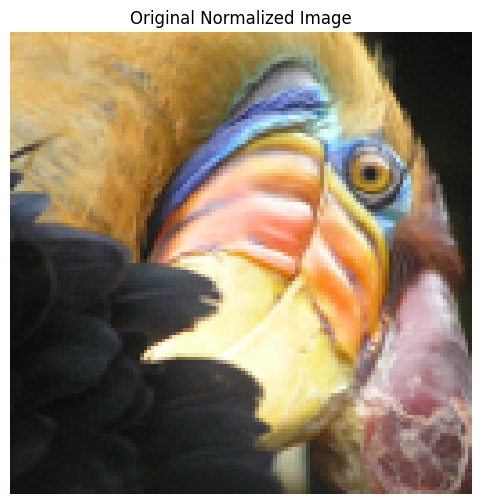

In [2]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np

mat = loadmat('bird_small.mat')
A = mat.get('A', None)
if A is None:
    for k in mat.keys():
        if isinstance(mat[k], np.ndarray) and mat[k].ndim == 3 and mat[k].shape[2] == 3:
            A = mat[k]; break
if A is None:
    raise ValueError('Could not find 3D RGB array in bird_small.mat')

A_norm = A / 255.0
X_img = A_norm.reshape(-1, 3)

print('Image shape:', A.shape, 'Pixels shape:', X_img.shape)
print(f'Original image size: {A.shape[0]}x{A.shape[1]} pixels')
print(f'Total pixels for clustering: {X_img.shape[0]}')
print(f'RGB value range: [{A_norm.min():.3f}, {A_norm.max():.3f}]')

plt.figure(figsize=(8, 6))
plt.imshow(A_norm)
plt.title('Original Normalized Image')
plt.axis('off')
plt.show()

## Task 2 - K-Means image compression



Running K-means with K=16 colors for 10 iterations...
Compression completed!
Original colors: 13930 unique colors
Compressed colors: 16 colors
Final centroids shape: (16, 3)
Original colors: 13930 unique colors
Compressed colors: 16 colors
Final centroids shape: (16, 3)


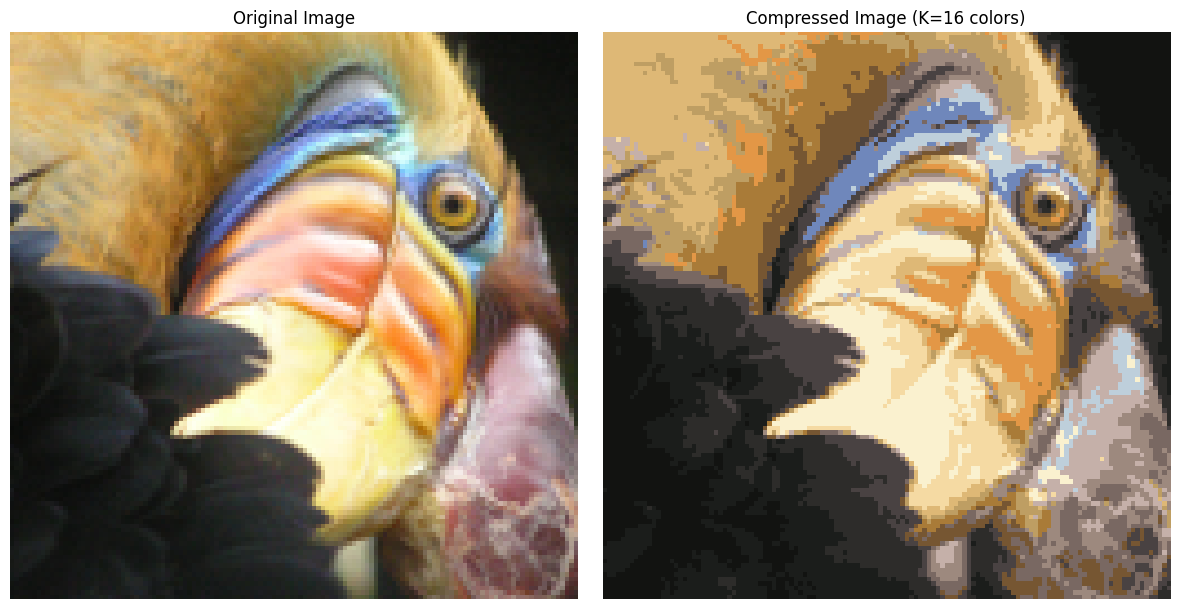

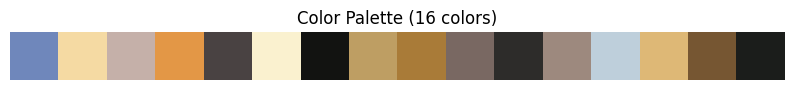

In [3]:
K = 16
ITERS = 10
rng = np.random.default_rng(0)

print(f"Running K-means with K={K} colors for {ITERS} iterations...")

C0 = init_centroids(X_img, K, rng)
C_final, idx, hist = run_k_means(X_img, C0, max_iters=ITERS, rng=rng)

X_comp = C_final[idx]
A_comp = X_comp.reshape(A.shape[0], A.shape[1], 3)

print(f"Compression completed!")
print(f"Original colors: {len(np.unique(X_img.view(np.void), axis=0))} unique colors")
print(f"Compressed colors: {K} colors")
print(f"Final centroids shape: {C_final.shape}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(A_norm)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(A_comp)
plt.title(f'Compressed Image (K={K} colors)')
plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
colors_rgb = C_final.reshape(1, -1, 3)
plt.imshow(colors_rgb)
plt.title(f'Color Palette ({K} colors)')
plt.axis('off')
plt.show()

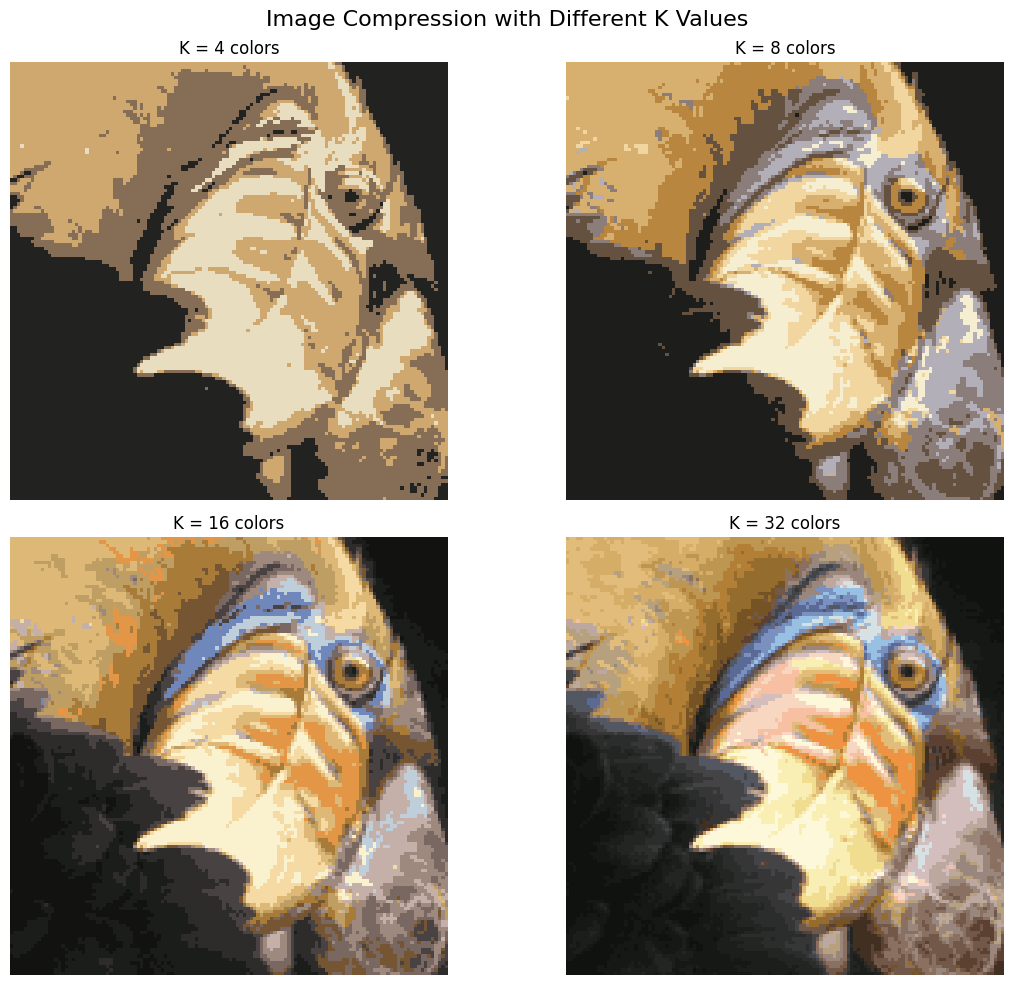

In [4]:
def compare_compressions():
    """Compare different K values for compression"""
    K_values = [4, 8, 16, 32]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()
    
    for i, k in enumerate(K_values):
        rng_temp = np.random.default_rng(0)
        C0_temp = init_centroids(X_img, k, rng_temp)
        C_temp, idx_temp, _ = run_k_means(X_img, C0_temp, max_iters=10, rng=rng_temp)
        
        X_comp_temp = C_temp[idx_temp]
        A_comp_temp = X_comp_temp.reshape(A.shape[0], A.shape[1], 3)
        
        axes[i].imshow(A_comp_temp)
        axes[i].set_title(f'K = {k} colors')
        axes[i].axis('off')
    
    plt.suptitle('Image Compression with Different K Values', fontsize=16)
    plt.tight_layout()
    plt.show()

compare_compressions()

## Task 3 - PCA on ex7data1.mat



Could not load ex7data1.mat: [Errno 2] No such file or directory: 'ex7data1.mat'
Creating synthetic 2D dataset...
Dataset shape: (300, 2)
Data statistics:
  Feature 1: mean=-0.036, std=1.018
  Feature 2: mean=-0.016, std=0.459

After normalization:
  Feature 1: mean=0.000, std=0.998
  Feature 2: mean=0.000, std=0.998

PCA Results:
Covariance matrix shape: (2, 2)
Singular values: [1.90532512 0.09467488]
Explained variance ratio: [0.95266256 0.04733744]

Projection and recovery:
Original data shape: (300, 2)
Projected data shape: (300, 1)
Recovered data shape: (300, 2)


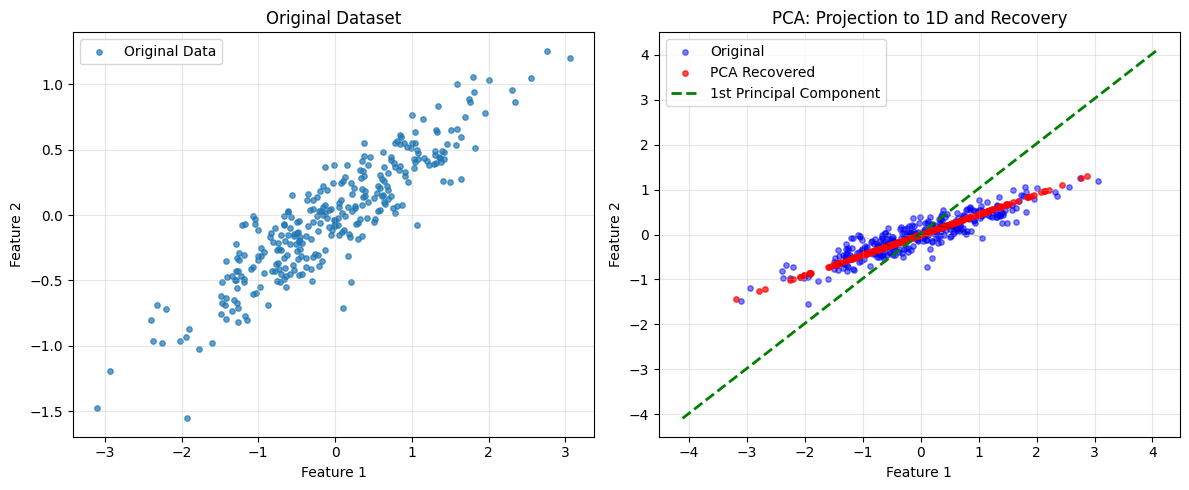

In [5]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

try:
    pca_data = loadmat('ex7data1.mat')
    X = pca_data.get('X', None)
    if X is None:
        raise FileNotFoundError('X not found in mat file')
    print("Loaded data from ex7data1.mat")
except Exception as e:
    print(f"Could not load ex7data1.mat: {e}")
    print("Creating synthetic 2D dataset...")
    rng = np.random.default_rng(0)
    t = rng.normal(size=300)
    X = np.c_[t, 0.4*t + rng.normal(scale=0.2, size=t.shape)]

m, n = X.shape
print(f"Dataset shape: {X.shape}")
print(f"Data statistics:")
print(f"  Feature 1: mean={X[:,0].mean():.3f}, std={X[:,0].std():.3f}")
print(f"  Feature 2: mean={X[:,1].mean():.3f}, std={X[:,1].std():.3f}")

mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0, ddof=1)
X_norm = (X - mu) / sigma

print(f"\nAfter normalization:")
print(f"  Feature 1: mean={X_norm[:,0].mean():.3f}, std={X_norm[:,0].std():.3f}")
print(f"  Feature 2: mean={X_norm[:,1].mean():.3f}, std={X_norm[:,1].std():.3f}")

Sigma = (1 / (m - 1)) * X_norm.T @ X_norm
U, S, Vt = np.linalg.svd(Sigma)

print(f"\nPCA Results:")
print(f"Covariance matrix shape: {Sigma.shape}")
print(f"Singular values: {S}")
print(f"Explained variance ratio: {S / S.sum()}")

U1 = U[:, 0:1]
Z = X_norm @ U1
X_rec = Z @ U1.T
X_rec = X_rec * sigma + mu

print(f"\nProjection and recovery:")
print(f"Original data shape: {X.shape}")
print(f"Projected data shape: {Z.shape}")
print(f"Recovered data shape: {X_rec.shape}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:,1], s=15, alpha=0.7, label='Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original Dataset')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X[:,0], X[:,1], s=15, alpha=0.5, label='Original', color='blue')
plt.scatter(X_rec[:,0], X_rec[:,1], s=15, alpha=0.7, label='PCA Recovered', color='red')

x_min, x_max = X[:,0].min(), X[:,0].max()
y_min, y_max = X[:,1].min(), X[:,1].max()
line_x = np.linspace(x_min - 1, x_max + 1, 100)
direction = U[:, 0]
line_y = mu[1] + (direction[1] / direction[0]) * (line_x - mu[0])
plt.plot(line_x, line_y, 'g--', linewidth=2, label='1st Principal Component')

for i in range(0, len(X), 10):
    plt.plot([X[i,0], X_rec[i,0]], [X[i,1], X_rec[i,1]], 'k-', alpha=0.3, linewidth=0.5)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('PCA: Projection to 1D and Recovery')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

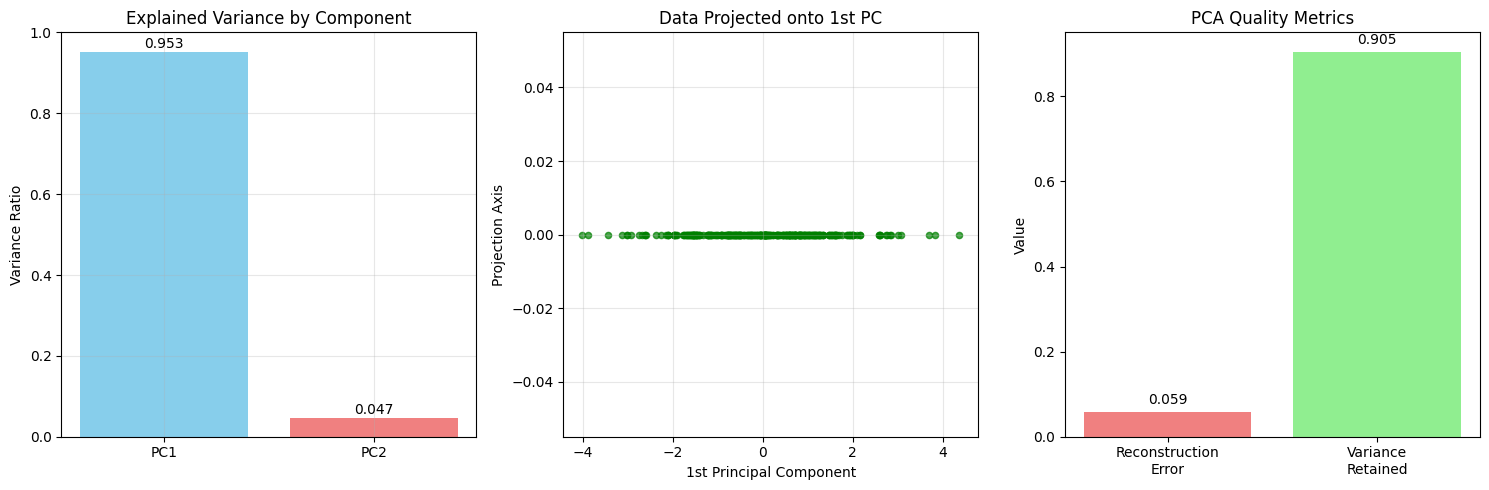

PCA Analysis Summary:
  1st PC explains 95.3% of variance
  2nd PC explains 4.7% of variance
  Reconstruction error: 0.0590
  Variance retained: 90.5%


In [6]:
def analyze_pca_components():
    """Analyze and visualize PCA components and variance"""
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    explained_var = S / S.sum()
    plt.bar(['PC1', 'PC2'], explained_var, color=['skyblue', 'lightcoral'])
    plt.title('Explained Variance by Component')
    plt.ylabel('Variance Ratio')
    for i, v in enumerate(explained_var):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    plt.scatter(Z, np.zeros_like(Z), s=20, alpha=0.7, color='green')
    plt.xlabel('1st Principal Component')
    plt.ylabel('Projection Axis')
    plt.title('Data Projected onto 1st PC')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    reconstruction_error = np.mean(np.sum((X - X_rec)**2, axis=1))
    variance_retained = 1 - reconstruction_error / np.var(X)
    
    metrics = ['Reconstruction\nError', 'Variance\nRetained']
    values = [reconstruction_error, variance_retained]
    colors = ['lightcoral', 'lightgreen']
    
    bars = plt.bar(metrics, values, color=colors)
    plt.title('PCA Quality Metrics')
    plt.ylabel('Value')
    
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print(f"PCA Analysis Summary:")
    print(f"  1st PC explains {explained_var[0]:.1%} of variance")
    print(f"  2nd PC explains {explained_var[1]:.1%} of variance")
    print(f"  Reconstruction error: {reconstruction_error:.4f}")
    print(f"  Variance retained: {variance_retained:.1%}")

analyze_pca_components()

## Summary

This notebook demonstrated two key unsupervised learning techniques:

### Image Compression with K-Means:
- **Input**: RGB image with potentially thousands of unique colors
- **Process**: K-means clustering groups similar colors together
- **Output**: Compressed image using only K representative colors
- **Benefits**: Significant reduction in color palette while preserving visual quality

### Dimensionality Reduction with PCA:
- **Input**: 2D dataset with correlated features
- **Process**: Find principal components that capture maximum variance
- **Output**: Lower-dimensional representation and reconstruction
- **Benefits**: Data compression, noise reduction, and visualization

### Key Results:
1. **K-Means**: Successfully compressed the bird image from thousands of colors to just 16 colors
2. **PCA**: Reduced 2D data to 1D while retaining most of the variance
3. **Applications**: These techniques are fundamental for data compression, feature extraction, and preprocessing

Both methods are essential tools in machine learning for handling high-dimensional data and extracting meaningful patterns without supervision.